# HLV DiscoGeM Experiment Dashboard

This notebook summarizes both the legacy single-level DiscoGeM runs and the new multilevel runs.

It covers:
- training traces and best dev metrics
- single-level test metrics
- multilevel test metrics with level1/level2/level3/overall breakdowns
- wall-clock reconstruction
- dataset split / label statistics


In [35]:
from __future__ import annotations
import csv
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid')


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / '.git').exists() or (candidate / 'pyproject.toml').exists():
            return candidate
    return start


ROOT = find_repo_root(Path.cwd())
RUN_ROOT = ROOT / 'outputs/discogem/runs'
RESULT_ROOT = ROOT / 'outputs/discogem/results_test'
MULTILEVEL_RESULT_ROOT = ROOT / 'outputs/discogem/results_test_multilevel'
DISCOGEM_PATH = ROOT / 'data/external/DiscoGeM/DiscoGeM 2.0/DiscoGeM2.0_annotation.tgz'
DISCOGEM_LANGUAGE = 'en'
print('ROOT =', ROOT)
print('RUN_ROOT exists =', RUN_ROOT.exists())
print('RESULT_ROOT exists =', RESULT_ROOT.exists())
print('MULTILEVEL_RESULT_ROOT exists =', MULTILEVEL_RESULT_ROOT.exists())
print('DISCOGEM_PATH exists =', DISCOGEM_PATH.exists())


def parse_result_name(name: str) -> dict:
    stem = name.removesuffix('__test_eval.json').removesuffix('__test.jsonl')
    level, model, head, objective_blob, seed_blob = stem.split('__', 4)
    if objective_blob.startswith('soft_label_loss_'):
        objective = 'soft_label_loss'
        loss = objective_blob[len('soft_label_loss_'):]
    elif objective_blob.startswith('regression_loss_'):
        objective = 'regression_loss'
        loss = objective_blob[len('regression_loss_'):]
    else:
        objective = 'unknown'
        loss = objective_blob
    seed = int(seed_blob.removeprefix('seed_'))
    result_mode = 'multilevel' if level == 'multilevel' else 'single'
    return {
        'level': level,
        'result_mode': result_mode,
        'safe_model': model,
        'head': head,
        'objective': objective,
        'loss': loss,
        'seed': seed,
        'run_name': f'{model}__{head}__{objective_blob}',
    }


def load_json(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def flatten_metrics(payload: dict, prefix: str = '') -> dict:
    flat = {}
    for key, value in payload.items():
        name = f'{prefix}{key}' if prefix else key
        if isinstance(value, dict):
            flat.update(flatten_metrics(value, prefix=f'{name}_'))
        else:
            flat[name] = value
    return flat


def extract_eval_history(trainer_state: dict) -> pd.DataFrame:
    rows = []
    for item in trainer_state.get('log_history', []):
        if 'eval_tvd' in item or 'eval_accuracy' in item or 'eval_kl_divergence' in item:
            rows.append(item)
    return pd.DataFrame(rows)


def collect_screening_runs(run_root: Path) -> tuple[pd.DataFrame, dict]:
    summary_rows = []
    histories = {}

    for level_dir in sorted(p for p in run_root.iterdir() if p.is_dir()):
        level = level_dir.name
        for run_dir in sorted(p for p in level_dir.iterdir() if p.is_dir()):
            for seed_dir in sorted(p for p in run_dir.iterdir() if p.is_dir() and p.name.startswith('seed_')):
                trainer_states = sorted(seed_dir.glob('checkpoint-*/trainer_state.json'))
                if not trainer_states:
                    continue
                latest_state_path = max(trainer_states, key=lambda p: int(p.parent.name.replace('checkpoint-', '')))
                trainer_state = load_json(latest_state_path)
                eval_df = extract_eval_history(trainer_state)
                if eval_df.empty:
                    continue
                meta = parse_result_name(f'{level}__{run_dir.name}__{seed_dir.name}__test_eval.json')
                best_step = trainer_state.get('best_global_step')
                best_row = eval_df.loc[eval_df['step'] == best_step]
                if best_row.empty and 'eval_tvd' in eval_df.columns:
                    best_row = eval_df.nsmallest(1, 'eval_tvd')
                if best_row.empty:
                    best_row = eval_df.iloc[[-1]]
                best_row = best_row.iloc[0].to_dict()
                final_row = eval_df.sort_values('step').iloc[-1].to_dict()
                histories[(level, run_dir.name, seed_dir.name)] = eval_df.sort_values('step').reset_index(drop=True)
                summary_rows.append({
                    **meta,
                    'best_global_step': best_step,
                    'best_metric': trainer_state.get('best_metric'),
                    'best_checkpoint': trainer_state.get('best_model_checkpoint'),
                    'num_eval_points': len(eval_df),
                    'train_batch_size': trainer_state.get('train_batch_size'),
                    'num_input_tokens_seen': trainer_state.get('num_input_tokens_seen'),
                    'best_epoch': best_row.get('epoch'),
                    'best_eval_tvd': best_row.get('eval_tvd'),
                    'best_eval_kl_divergence': best_row.get('eval_kl_divergence'),
                    'best_eval_accuracy': best_row.get('eval_accuracy'),
                    'best_eval_samples_per_second': best_row.get('eval_samples_per_second'),
                    'final_epoch': final_row.get('epoch'),
                    'final_eval_tvd': final_row.get('eval_tvd'),
                    'final_eval_kl_divergence': final_row.get('eval_kl_divergence'),
                    'final_eval_accuracy': final_row.get('eval_accuracy'),
                })
    summary_df = pd.DataFrame(summary_rows)
    if not summary_df.empty:
        summary_df = summary_df.sort_values(
            ['result_mode', 'level', 'best_eval_tvd', 'best_eval_kl_divergence', 'best_eval_accuracy'],
            ascending=[True, True, True, True, False],
        ).reset_index(drop=True)
    return summary_df, histories


def collect_test_results(result_roots: dict[str, Path]) -> pd.DataFrame:
    rows = []
    for result_mode, result_root in result_roots.items():
        if not result_root.exists():
            continue
        for path in sorted(result_root.glob('*__test_eval.json')):
            meta = parse_result_name(path.name)
            payload = load_json(path)
            row = {**meta, 'source_root': result_mode}
            if meta['result_mode'] == 'multilevel' and all(key in payload for key in ('level1', 'level2', 'level3', 'overall')):
                for block_name in ('level1', 'level2', 'level3', 'overall'):
                    block = payload.get(block_name, {})
                    if isinstance(block, dict):
                        for metric_name, value in block.items():
                            row[f'{block_name}_{metric_name}'] = value
                overall = payload.get('overall', {})
                if isinstance(overall, dict):
                    row['accuracy'] = overall.get('accuracy')
                    row['tvd_mean'] = overall.get('tvd_mean')
                    row['jsd_mean'] = overall.get('jsd_mean')
                    row['kl_mean'] = overall.get('kl_mean')
                    row['soft_micro_f1'] = overall.get('soft_micro_f1')
                    row['soft_macro_f1'] = overall.get('soft_macro_f1')
                    row['distance_correlation'] = overall.get('distance_correlation')
            else:
                row.update(payload)
            rows.append(row)
    df = pd.DataFrame(rows)
    if not df.empty:
        df['run_label'] = df['safe_model'] + ' | ' + df['head'] + ' | ' + df['loss']
        sort_cols = [col for col in ['result_mode', 'level', 'safe_model', 'head', 'loss'] if col in df.columns]
        df = df.sort_values(sort_cols).reset_index(drop=True)
    return df


def format_hms_from_seconds(seconds: float) -> str:
    total_seconds = int(round(seconds))
    hours = total_seconds // 3600
    mins = (total_seconds % 3600) // 60
    secs = total_seconds % 60
    return f'{hours:02d}:{mins:02d}:{secs:02d}'


def collect_wall_clock_summary(run_root: Path, result_roots: dict[str, Path]) -> pd.DataFrame:
    checkpoint_rows = []
    for checkpoint_path in run_root.glob('**/checkpoint-*/trainer_state.json'):
        level = checkpoint_path.parts[-5] if len(checkpoint_path.parts) >= 5 else 'unknown'
        checkpoint_rows.append({'level': level, 'path': checkpoint_path, 'mtime': checkpoint_path.stat().st_mtime})

    eval_rows = []
    for result_mode, result_root in result_roots.items():
        if not result_root.exists():
            continue
        for eval_path in result_root.glob('*__test_eval.json'):
            meta = parse_result_name(eval_path.name)
            eval_rows.append({'level': meta['level'], 'result_mode': result_mode, 'path': eval_path, 'mtime': eval_path.stat().st_mtime})

    rows = []
    if checkpoint_rows and eval_rows:
        first_checkpoint = min(checkpoint_rows, key=lambda x: x['mtime'])
        last_eval = max(eval_rows, key=lambda x: x['mtime'])
        rows.append({
            'scope': 'all',
            'completed_runs': len(eval_rows),
            'wall_clock_hms': format_hms_from_seconds(max(0.0, last_eval['mtime'] - first_checkpoint['mtime'])),
            'wall_clock_seconds': max(0.0, last_eval['mtime'] - first_checkpoint['mtime']),
            'first_observed_checkpoint': str(first_checkpoint['path']),
            'last_observed_test_eval': str(last_eval['path']),
        })

        for level in sorted({row['level'] for row in eval_rows}):
            level_checkpoints = [row for row in checkpoint_rows if row['level'] == level]
            level_evals = [row for row in eval_rows if row['level'] == level]
            if not level_checkpoints or not level_evals:
                continue
            level_first = min(level_checkpoints, key=lambda x: x['mtime'])
            level_last = max(level_evals, key=lambda x: x['mtime'])
            rows.append({
                'scope': level,
                'completed_runs': len(level_evals),
                'wall_clock_hms': format_hms_from_seconds(max(0.0, level_last['mtime'] - level_first['mtime'])),
                'wall_clock_seconds': max(0.0, level_last['mtime'] - level_first['mtime']),
                'first_observed_checkpoint': str(level_first['path']),
                'last_observed_test_eval': str(level_last['path']),
            })
    return pd.DataFrame(rows)


screen_df, screen_histories = collect_screening_runs(RUN_ROOT)
result_roots = {'single': RESULT_ROOT, 'multilevel': MULTILEVEL_RESULT_ROOT}
test_df = collect_test_results(result_roots)
single_test_df = test_df[test_df['result_mode'] == 'single'].copy() if not test_df.empty else pd.DataFrame()
multilevel_test_df = test_df[test_df['result_mode'] == 'multilevel'].copy() if not test_df.empty else pd.DataFrame()
wall_clock_df = collect_wall_clock_summary(RUN_ROOT, result_roots)
print('screen runs =', len(screen_df))
print('test result files =', len(test_df))
print('single-level test result files =', len(single_test_df))
print('multilevel test result files =', len(multilevel_test_df))
print('wall clock rows =', len(wall_clock_df))


ROOT = /nfs/mainlp01/xcheng/nli-toolkits
RUN_ROOT exists = True
RESULT_ROOT exists = True
MULTILEVEL_RESULT_ROOT exists = True
DISCOGEM_PATH exists = True
screen runs = 128
test result files = 128
single-level test result files = 96
multilevel test result files = 32
wall clock rows = 5


In [36]:
if screen_df.empty:
    print('No screening runs found under', RUN_ROOT)
else:
    display(screen_df[['result_mode', 'level', 'safe_model', 'head', 'loss', 'best_eval_tvd', 'best_eval_kl_divergence', 'best_eval_accuracy', 'best_epoch', 'best_eval_samples_per_second']])


,result_mode,level,safe_model,head,loss,best_eval_tvd,best_eval_kl_divergence,best_eval_accuracy,best_epoch,best_eval_samples_per_second
0,multilevel,multilevel,roberta-base,multilevel_classification,kl_div,0.335391,0.519538,0.601598,15.0,871.137
1,multilevel,multilevel,roberta-base,multilevel_classification,cross_entropy,0.343555,0.557049,0.591895,24.0,794.773
2,multilevel,multilevel,studio-ousia_luke-base,multilevel_classification,kl_div,0.349346,0.564577,0.587900,23.0,737.308
3,multilevel,multilevel,studio-ousia_luke-base,multilevel_classification,cross_entropy,0.356502,0.588703,0.557648,29.0,759.955
4,multilevel,multilevel,microsoft_deberta-v3-base,multilevel_classification,kl_div,0.358027,0.564286,0.555936,9.0,577.538
5,multilevel,multilevel,bert-base-uncased,multilevel_classification,kl_div,0.363850,0.600063,0.533105,20.0,1023.249
6,multilevel,multilevel,microsoft_deberta-v3-base,multilevel_classification,cross_entropy,0.366067,0.602489,0.535959,10.0,546.149
7,multilevel,multilevel,bert-base-uncased,multilevel_classification,cross_entropy,0.366761,0.612647,0.518265,22.0,1039.333
8,multilevel,multilevel,microsoft_infoxlm-base,multilevel_classification,cross_entropy,0.371838,0.591928,0.546804,21.0,807.261
9,multilevel,multilevel,microsoft_infoxlm-base,multilevel_classification,kl_div,0.374540,0.600855,0.548516,20.0,745.953


In [37]:
if test_df.empty:
    print('No test eval JSON found under', RESULT_ROOT, 'or', MULTILEVEL_RESULT_ROOT)
else:
    preferred_cols = ['result_mode', 'level', 'safe_model', 'head', 'loss', 'accuracy', 'tvd_mean', 'jsd_mean', 'kl_mean', 'soft_micro_f1', 'soft_macro_f1', 'distance_correlation', 'overall_accuracy', 'overall_tvd_mean', 'overall_jsd_mean', 'overall_kl_mean', 'overall_soft_micro_f1', 'overall_soft_macro_f1', 'overall_distance_correlation']
    display(test_df[[col for col in preferred_cols if col in test_df.columns]])


,result_mode,level,safe_model,head,loss,accuracy,tvd_mean,jsd_mean,kl_mean,soft_micro_f1,soft_macro_f1,distance_correlation,overall_accuracy,overall_tvd_mean,overall_jsd_mean,overall_kl_mean,overall_soft_micro_f1,overall_soft_macro_f1,overall_distance_correlation
0,multilevel,multilevel,Twitter_twhin-bert-base,multilevel_classification,cross_entropy,0.476687,0.409265,0.464249,0.687368,0.590735,0.290973,0.432644,0.476687,0.409265,0.464249,0.687368,0.590735,0.290973,0.432644
1,multilevel,multilevel,Twitter_twhin-bert-base,multilevel_classification,kl_div,0.454967,0.422821,0.476932,0.718113,0.577179,0.285195,0.404977,0.454967,0.422821,0.476932,0.718113,0.577179,0.285195,0.404977
2,multilevel,multilevel,Twitter_twhin-bert-base,multilevel_regression,bce,0.437011,0.446160,0.499042,0.752271,0.553840,0.280571,0.390902,0.437011,0.446160,0.499042,0.752271,0.553840,0.280571,0.390902
3,multilevel,multilevel,Twitter_twhin-bert-base,multilevel_regression,mse,0.425717,0.513381,0.556963,0.921906,0.486619,0.269076,0.342772,0.425717,0.513381,0.556963,0.921906,0.486619,0.269076,0.342772
4,multilevel,multilevel,answerdotai_ModernBERT-base,multilevel_classification,cross_entropy,0.431219,0.433577,0.486363,0.728108,0.566423,0.274125,0.320710,0.431219,0.433577,0.486363,0.728108,0.566423,0.274125,0.320710
5,multilevel,multilevel,answerdotai_ModernBERT-base,multilevel_classification,kl_div,0.421373,0.433577,0.485974,0.720617,0.566423,0.271946,0.335287,0.421373,0.433577,0.485974,0.720617,0.566423,0.271946,0.335287
6,multilevel,multilevel,answerdotai_ModernBERT-base,multilevel_regression,bce,0.418187,0.451109,0.500901,0.822526,0.548891,0.263388,0.299848,0.418187,0.451109,0.500901,0.822526,0.548891,0.263388,0.299848
7,multilevel,multilevel,answerdotai_ModernBERT-base,multilevel_regression,mse,0.427744,0.483332,0.531176,0.868945,0.516668,0.269935,0.303228,0.427744,0.483332,0.531176,0.868945,0.516668,0.269935,0.303228
8,multilevel,multilevel,bert-base-uncased,multilevel_classification,cross_entropy,0.562409,0.356990,0.417051,0.585782,0.643010,0.325513,0.588795,0.562409,0.356990,0.417051,0.585782,0.643010,0.325513,0.588795
9,multilevel,multilevel,bert-base-uncased,multilevel_classification,kl_div,0.566174,0.357688,0.418808,0.583155,0.642312,0.326932,0.585729,0.566174,0.357688,0.418808,0.583155,0.642312,0.326932,0.585729


In [38]:
if not single_test_df.empty:
    single_summary = (
        single_test_df.groupby(['level', 'head', 'loss'], as_index=False)
        .agg(
            accuracy=('accuracy', 'mean'),
            tvd_mean=('tvd_mean', 'mean'),
            jsd_mean=('jsd_mean', 'mean'),
            kl_mean=('kl_mean', 'mean'),
            soft_micro_f1=('soft_micro_f1', 'mean'),
            soft_macro_f1=('soft_macro_f1', 'mean'),
            distance_correlation=('distance_correlation', 'mean'),
            runs=('safe_model', 'count'),
        )
        .sort_values(['level', 'tvd_mean', 'kl_mean', 'accuracy'], ascending=[True, True, True, False])
        .reset_index(drop=True)
    )
    display(single_summary)

if not multilevel_test_df.empty:
    multilevel_summary = (
        multilevel_test_df.groupby(['head', 'loss'], as_index=False)
        .agg(
            overall_accuracy=('accuracy', 'mean'),
            overall_tvd_mean=('tvd_mean', 'mean'),
            overall_jsd_mean=('jsd_mean', 'mean'),
            overall_kl_mean=('kl_mean', 'mean'),
            overall_soft_micro_f1=('soft_micro_f1', 'mean'),
            overall_soft_macro_f1=('soft_macro_f1', 'mean'),
            overall_distance_correlation=('distance_correlation', 'mean'),
            level1_accuracy=('level1_accuracy', 'mean'),
            level2_accuracy=('level2_accuracy', 'mean'),
            level3_accuracy=('level3_accuracy', 'mean'),
            runs=('safe_model', 'count'),
        )
        .sort_values(['overall_tvd_mean', 'overall_kl_mean', 'overall_accuracy'], ascending=[True, True, False])
        .reset_index(drop=True)
    )
    display(multilevel_summary)


,level,head,loss,accuracy,tvd_mean,jsd_mean,kl_mean,soft_micro_f1,soft_macro_f1,distance_correlation,runs
0,level1,classification,cross_entropy,0.655951,0.272719,0.322480,0.336327,0.727281,0.541788,0.553103,8
1,level1,classification,kl_div,0.650521,0.272843,0.322008,0.340681,0.727157,0.541357,0.550857,8
2,level1,per_label_regression,bce,0.644331,0.280286,0.329367,0.356884,0.719714,0.534342,0.532412,8
3,level1,per_label_regression,mse,0.640747,0.284534,0.337849,0.348185,0.715466,0.538809,0.531114,8
4,level2,classification,kl_div,0.489357,0.392559,0.454306,0.648296,0.607441,0.266435,0.518213,8
5,level2,classification,cross_entropy,0.493050,0.392776,0.455385,0.647075,0.607224,0.267457,0.519158,8
6,level2,per_label_regression,bce,0.457863,0.425251,0.489238,0.697737,0.574749,0.243601,0.460923,8
7,level2,per_label_regression,mse,0.450043,0.475008,0.538755,0.798586,0.524992,0.230274,0.434592,8
8,level3,classification,cross_entropy,0.442659,0.454495,0.518422,0.845671,0.545505,0.137634,0.530429,8
9,level3,classification,kl_div,0.448957,0.454825,0.518941,0.861940,0.545175,0.137758,0.531898,8


,head,loss,overall_accuracy,overall_tvd_mean,overall_jsd_mean,overall_kl_mean,overall_soft_micro_f1,overall_soft_macro_f1,overall_distance_correlation,level1_accuracy,level2_accuracy,level3_accuracy,runs
0,multilevel_classification,cross_entropy,0.525159,0.377801,0.436411,0.623466,0.622199,0.312907,0.523077,0.633471,0.487185,0.454822,8
1,multilevel_classification,kl_div,0.526209,0.378103,0.437413,0.617540,0.621897,0.313013,0.524835,0.634340,0.489248,0.455039,8
2,multilevel_regression,bce,0.492869,0.417436,0.475229,0.696115,0.582564,0.293984,0.479470,0.616964,0.457646,0.403997,8
3,multilevel_regression,mse,0.495330,0.479955,0.530680,0.836809,0.520045,0.285896,0.470519,0.620330,0.456560,0.409101,8


,safe_model,head,loss,level,accuracy,tvd_mean,jsd_mean,kl_mean,soft_micro_f1,soft_macro_f1,distance_correlation,mode
0,Twitter_twhin-bert-base,multilevel_classification,cross_entropy,level1,0.595135,0.303756,0.350074,0.399109,0.696244,0.511794,0.442763,multilevel
1,answerdotai_ModernBERT-base,multilevel_classification,cross_entropy,level1,0.555169,0.329772,0.373949,0.434031,0.670228,0.485419,0.315679,multilevel
2,bert-base-uncased,multilevel_classification,cross_entropy,level1,0.657689,0.263839,0.314393,0.337935,0.736161,0.550466,0.601563,multilevel
3,microsoft_deberta-v3-base,multilevel_classification,cross_entropy,level1,0.658558,0.273005,0.320203,0.354899,0.726995,0.530485,0.567431,multilevel
4,microsoft_infoxlm-base,multilevel_classification,cross_entropy,level1,0.660295,0.274309,0.324871,0.335080,0.725691,0.547794,0.580236,multilevel
5,roberta-base,multilevel_classification,cross_entropy,level1,0.663771,0.257230,0.306682,0.329664,0.742770,0.559378,0.602161,multilevel
6,studio-ousia_luke-base,multilevel_classification,cross_entropy,level1,0.642050,0.265943,0.314652,0.337407,0.734057,0.554802,0.577733,multilevel
7,xlm-roberta-base,multilevel_classification,cross_entropy,level1,0.635100,0.280492,0.329065,0.363760,0.719508,0.538507,0.555457,multilevel
8,Twitter_twhin-bert-base,multilevel_classification,kl_div,level1,0.589922,0.315184,0.360085,0.421768,0.684816,0.501535,0.415204,multilevel
9,answerdotai_ModernBERT-base,multilevel_classification,kl_div,level1,0.523892,0.330180,0.374297,0.425767,0.669820,0.484275,0.340502,multilevel


,level,mode,safe_model,head,loss,accuracy,tvd_mean,jsd_mean,kl_mean,soft_micro_f1,soft_macro_f1,distance_correlation
0,level1,single,studio-ousia_luke-base,classification,kl_div,0.715899,0.242720,0.295604,0.288583,0.757280,0.565121,0.642295
1,level1,single,studio-ousia_luke-base,classification,cross_entropy,0.691573,0.246202,0.299573,0.282676,0.753798,0.566645,0.630842
2,level1,single,roberta-base,classification,kl_div,0.676803,0.251501,0.300024,0.349298,0.748499,0.565864,0.612751
3,level1,single,roberta-base,classification,cross_entropy,0.684622,0.251928,0.302231,0.310352,0.748072,0.567149,0.631158
4,level1,single,roberta-base,per_label_regression,mse,0.680278,0.253343,0.308188,0.295462,0.746657,0.571972,0.628980
5,level1,multilevel,roberta-base,multilevel_classification,kl_div,0.688097,0.254096,0.304360,0.302743,0.745904,0.565470,0.615918
6,level1,single,roberta-base,per_label_regression,bce,0.690704,0.255163,0.306865,0.305701,0.744837,0.564255,0.622449
7,level1,multilevel,studio-ousia_luke-base,multilevel_classification,kl_div,0.671590,0.255265,0.306201,0.319974,0.744735,0.565696,0.618623
8,level1,multilevel,roberta-base,multilevel_classification,cross_entropy,0.663771,0.257230,0.306682,0.329664,0.742770,0.559378,0.602161
9,level1,single,bert-base-uncased,classification,cross_entropy,0.687228,0.258964,0.313161,0.305824,0.741036,0.552075,0.604959


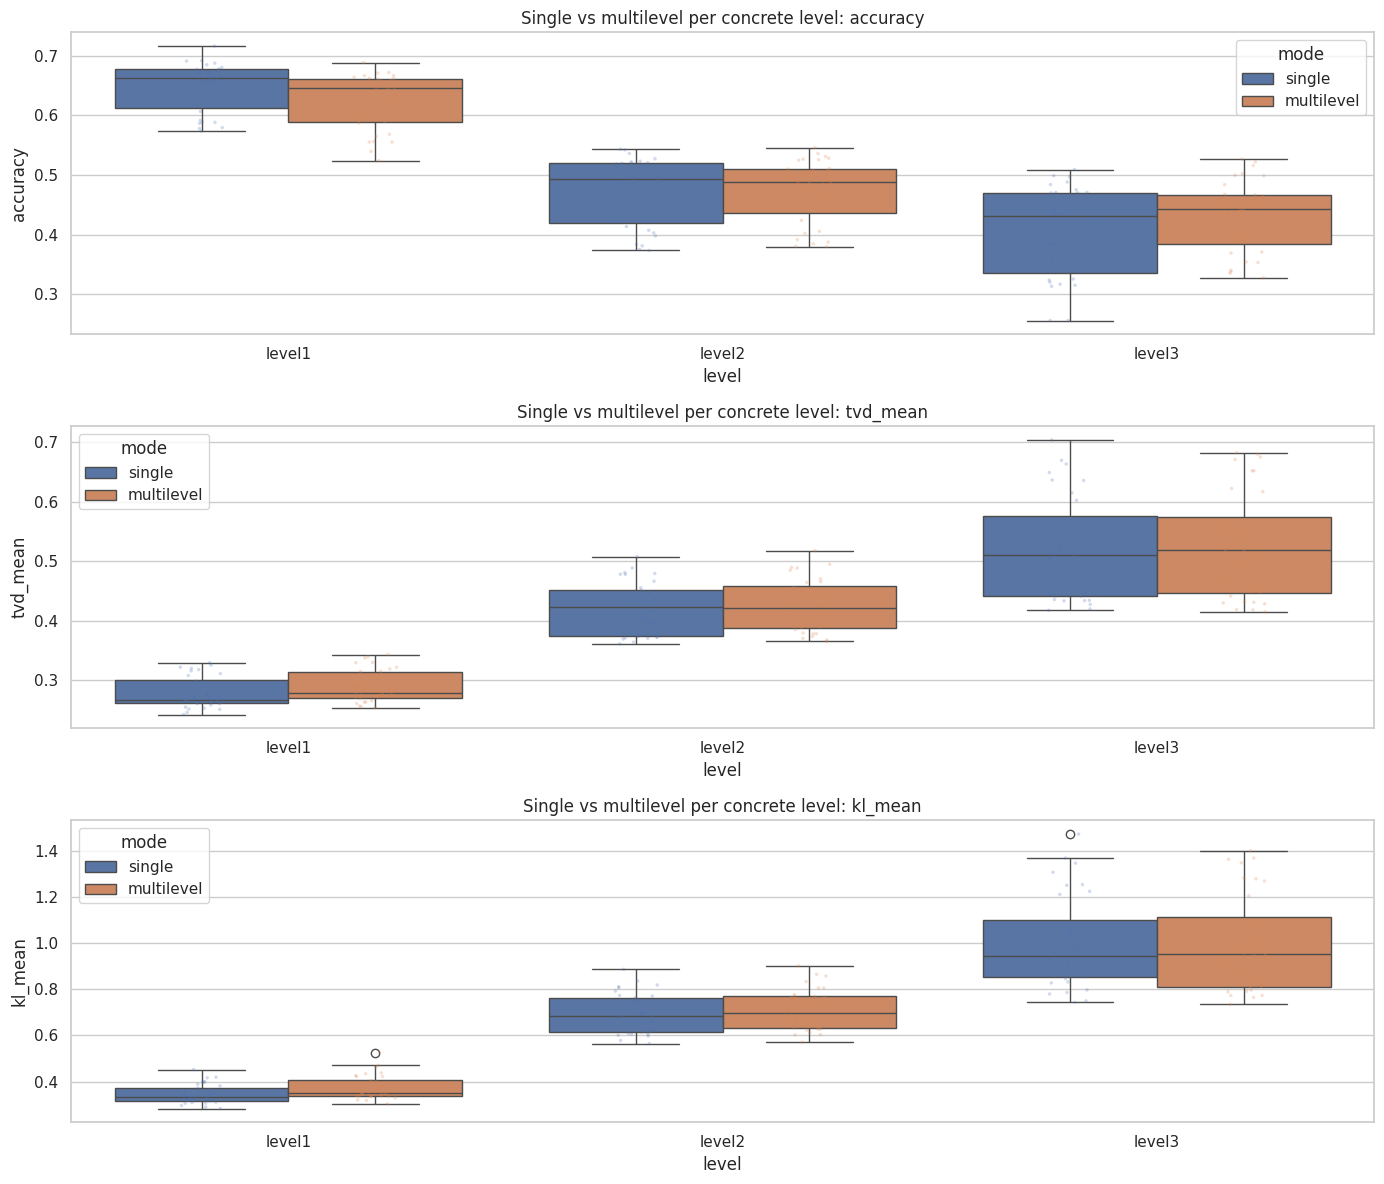

In [39]:
comparison_rows = []

metric_names = ['accuracy', 'tvd_mean', 'jsd_mean', 'kl_mean', 'soft_micro_f1', 'soft_macro_f1', 'distance_correlation']

if not single_test_df.empty:
    single_rows = single_test_df.copy()
    single_rows = single_rows[['safe_model', 'head', 'loss', 'level', *[c for c in metric_names if c in single_rows.columns]]].copy()
    single_rows['mode'] = 'single'
    comparison_rows.append(single_rows)

if not multilevel_test_df.empty:
    for level in ['level1', 'level2', 'level3']:
        rename_map = {
            f'{level}_accuracy': 'accuracy',
            f'{level}_tvd_mean': 'tvd_mean',
            f'{level}_jsd_mean': 'jsd_mean',
            f'{level}_kl_mean': 'kl_mean',
            f'{level}_soft_micro_f1': 'soft_micro_f1',
            f'{level}_soft_macro_f1': 'soft_macro_f1',
            f'{level}_distance_correlation': 'distance_correlation',
        }
        available = [src for src in rename_map if src in multilevel_test_df.columns]
        if not available:
            continue
        level_rows = multilevel_test_df[['safe_model', 'head', 'loss', *available]].copy()
        level_rows = level_rows.rename(columns={src: dst for src, dst in rename_map.items() if src in available})
        level_rows['level'] = level
        level_rows['mode'] = 'multilevel'
        comparison_rows.append(level_rows[['safe_model', 'head', 'loss', 'level', 'mode', *[c for c in metric_names if c in level_rows.columns]]])

if comparison_rows:
    comparison_df = pd.concat(comparison_rows, ignore_index=True)
    comparison_df['level'] = pd.Categorical(comparison_df['level'], categories=['level1', 'level2', 'level3'], ordered=True)
    display(comparison_df.sort_values(['level', 'mode', 'head', 'loss', 'safe_model']).reset_index(drop=True))

    tvd_rank_cols = ['level', 'mode', 'safe_model', 'head', 'loss']
    tvd_rank_cols += [col for col in ['accuracy', 'tvd_mean', 'jsd_mean', 'kl_mean', 'soft_micro_f1', 'soft_macro_f1', 'distance_correlation'] if col in comparison_df.columns]
    tvd_ranked_df = comparison_df[tvd_rank_cols].copy()
    tvd_ranked_df = tvd_ranked_df.sort_values(['level', 'tvd_mean', 'mode', 'head', 'loss', 'safe_model'], ascending=[True, True, True, True, True, True]).reset_index(drop=True)
    display(tvd_ranked_df)

    plot_metrics = [metric for metric in ['accuracy', 'tvd_mean', 'kl_mean'] if metric in comparison_df.columns]
    if plot_metrics:
        fig, axes = plt.subplots(len(plot_metrics), 1, figsize=(14, 4 * len(plot_metrics)), squeeze=False)
        for ax, metric in zip(axes.flat, plot_metrics):
            sns.boxplot(data=comparison_df, x='level', y=metric, hue='mode', ax=ax)
            sns.stripplot(data=comparison_df, x='level', y=metric, hue='mode', dodge=True, alpha=0.25, size=2.5, ax=ax)
            ax.set_title(f'Single vs multilevel per concrete level: {metric}')
            ax.set_xlabel('level')
            ax.set_ylabel(metric)
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles[:2], labels[:2], title='mode', loc='best')
        plt.tight_layout()
        plt.show()


In [40]:
if not single_test_df.empty:
    single_summary = (
        single_test_df.groupby(['level', 'head', 'loss'], as_index=False)
        .agg(
            accuracy=('accuracy', 'mean'),
            tvd_mean=('tvd_mean', 'mean'),
            jsd_mean=('jsd_mean', 'mean'),
            kl_mean=('kl_mean', 'mean'),
            soft_micro_f1=('soft_micro_f1', 'mean'),
            soft_macro_f1=('soft_macro_f1', 'mean'),
            distance_correlation=('distance_correlation', 'mean'),
            runs=('safe_model', 'count'),
        )
        .sort_values(['level', 'tvd_mean', 'kl_mean', 'accuracy'], ascending=[True, True, True, False])
        .reset_index(drop=True)
    )
    display(single_summary)

if not multilevel_test_df.empty:
    multilevel_summary = (
        multilevel_test_df.groupby(['head', 'loss'], as_index=False)
        .agg(
            overall_accuracy=('accuracy', 'mean'),
            overall_tvd_mean=('tvd_mean', 'mean'),
            overall_jsd_mean=('jsd_mean', 'mean'),
            overall_kl_mean=('kl_mean', 'mean'),
            overall_soft_micro_f1=('soft_micro_f1', 'mean'),
            overall_soft_macro_f1=('soft_macro_f1', 'mean'),
            overall_distance_correlation=('distance_correlation', 'mean'),
            level1_accuracy=('level1_accuracy', 'mean'),
            level2_accuracy=('level2_accuracy', 'mean'),
            level3_accuracy=('level3_accuracy', 'mean'),
            runs=('safe_model', 'count'),
        )
        .sort_values(['overall_tvd_mean', 'overall_kl_mean', 'overall_accuracy'], ascending=[True, True, False])
        .reset_index(drop=True)
    )
    display(multilevel_summary)


,level,head,loss,accuracy,tvd_mean,jsd_mean,kl_mean,soft_micro_f1,soft_macro_f1,distance_correlation,runs
0,level1,classification,cross_entropy,0.655951,0.272719,0.322480,0.336327,0.727281,0.541788,0.553103,8
1,level1,classification,kl_div,0.650521,0.272843,0.322008,0.340681,0.727157,0.541357,0.550857,8
2,level1,per_label_regression,bce,0.644331,0.280286,0.329367,0.356884,0.719714,0.534342,0.532412,8
3,level1,per_label_regression,mse,0.640747,0.284534,0.337849,0.348185,0.715466,0.538809,0.531114,8
4,level2,classification,kl_div,0.489357,0.392559,0.454306,0.648296,0.607441,0.266435,0.518213,8
5,level2,classification,cross_entropy,0.493050,0.392776,0.455385,0.647075,0.607224,0.267457,0.519158,8
6,level2,per_label_regression,bce,0.457863,0.425251,0.489238,0.697737,0.574749,0.243601,0.460923,8
7,level2,per_label_regression,mse,0.450043,0.475008,0.538755,0.798586,0.524992,0.230274,0.434592,8
8,level3,classification,cross_entropy,0.442659,0.454495,0.518422,0.845671,0.545505,0.137634,0.530429,8
9,level3,classification,kl_div,0.448957,0.454825,0.518941,0.861940,0.545175,0.137758,0.531898,8


,head,loss,overall_accuracy,overall_tvd_mean,overall_jsd_mean,overall_kl_mean,overall_soft_micro_f1,overall_soft_macro_f1,overall_distance_correlation,level1_accuracy,level2_accuracy,level3_accuracy,runs
0,multilevel_classification,cross_entropy,0.525159,0.377801,0.436411,0.623466,0.622199,0.312907,0.523077,0.633471,0.487185,0.454822,8
1,multilevel_classification,kl_div,0.526209,0.378103,0.437413,0.617540,0.621897,0.313013,0.524835,0.634340,0.489248,0.455039,8
2,multilevel_regression,bce,0.492869,0.417436,0.475229,0.696115,0.582564,0.293984,0.479470,0.616964,0.457646,0.403997,8
3,multilevel_regression,mse,0.495330,0.479955,0.530680,0.836809,0.520045,0.285896,0.470519,0.620330,0.456560,0.409101,8


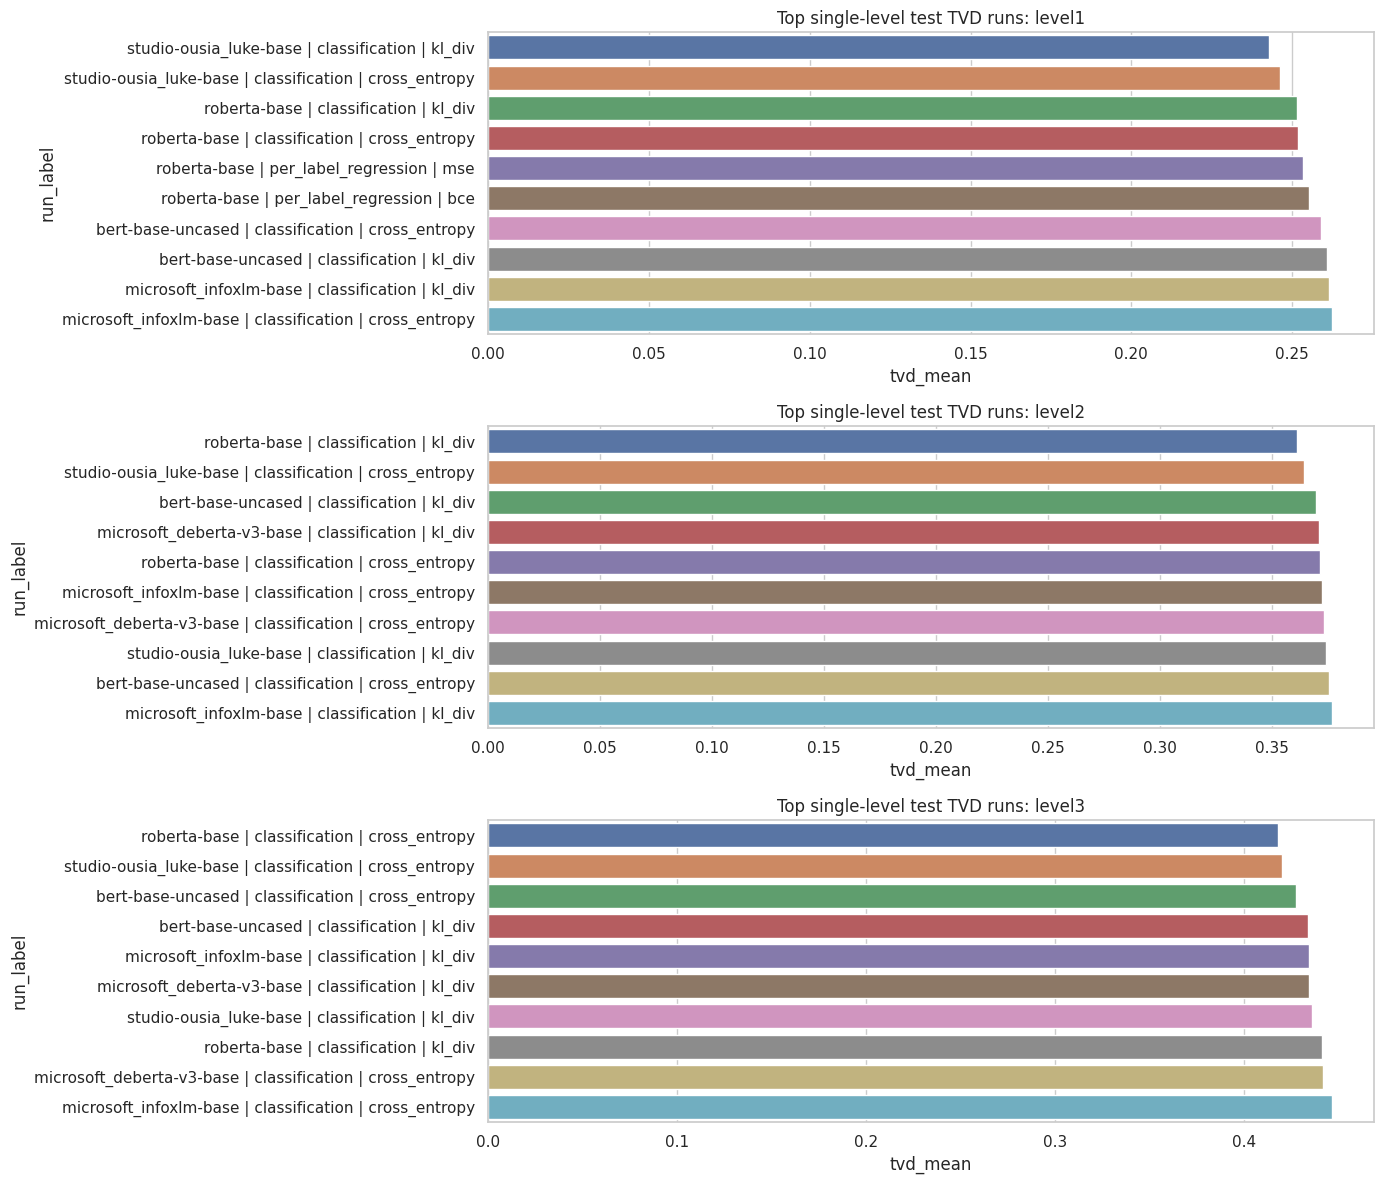

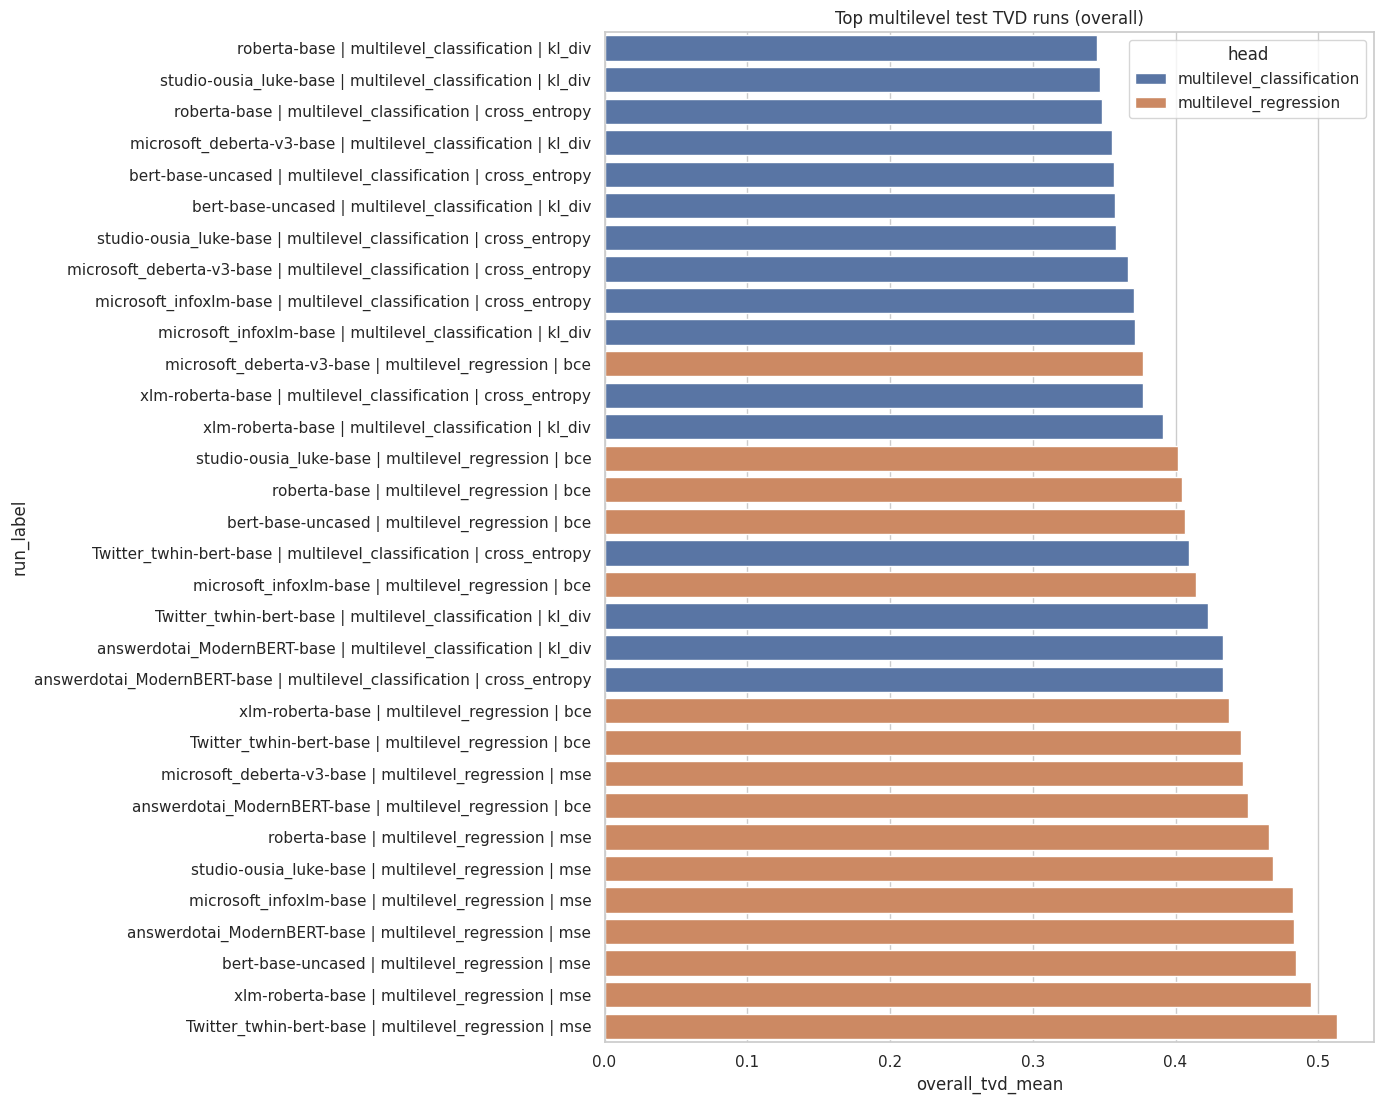

In [41]:
if not single_test_df.empty:
    best_per_level = single_test_df.sort_values(['level', 'tvd_mean', 'kl_mean', 'accuracy'], ascending=[True, True, True, False]).groupby('level').head(10)
    levels = list(best_per_level['level'].drop_duplicates())
    fig, axes = plt.subplots(len(levels), 1, figsize=(14, 4 * len(levels)), squeeze=False)
    for ax, level in zip(axes.flat, levels):
        level_df = best_per_level[best_per_level['level'] == level].copy()
        sns.barplot(data=level_df, x='tvd_mean', y='run_label', hue='run_label', dodge=False, legend=False, ax=ax)
        ax.set_title(f'Top single-level test TVD runs: {level}')
        ax.set_xlabel('tvd_mean')
        ax.set_ylabel('run_label')
    plt.tight_layout()
    plt.show()

if not multilevel_test_df.empty:
    best_multi = multilevel_test_df.sort_values(['overall_tvd_mean', 'overall_kl_mean', 'overall_accuracy'], ascending=[True, True, False]).groupby(['head', 'loss']).head(10)
    fig, ax = plt.subplots(figsize=(14, max(4, 0.35 * len(best_multi))))
    sns.barplot(data=best_multi, x='overall_tvd_mean', y='run_label', hue='head', dodge=False, ax=ax)
    ax.set_title('Top multilevel test TVD runs (overall)')
    ax.set_xlabel('overall_tvd_mean')
    ax.set_ylabel('run_label')
    plt.tight_layout()
    plt.show()


In [42]:
if wall_clock_df.empty:
    print('No wall-clock summary could be reconstructed from current outputs.')
else:
    print('Wall-clock time reconstructed from the earliest observed checkpoint to the latest observed test eval.')
    display(wall_clock_df)


Wall-clock time reconstructed from the earliest observed checkpoint to the latest observed test eval.


,scope,completed_runs,wall_clock_hms,wall_clock_seconds,first_observed_checkpoint,last_observed_test_eval
0,all,128,24:48:02,89282.062239,/nfs/mainlp01/xcheng/nli-toolkits/outputs/...,/nfs/mainlp01/xcheng/nli-toolkits/outputs/...
1,level1,32,14:03:04,50583.640393,/nfs/mainlp01/xcheng/nli-toolkits/outputs/...,/nfs/mainlp01/xcheng/nli-toolkits/outputs/...
2,level2,32,14:26:13,51972.632178,/nfs/mainlp01/xcheng/nli-toolkits/outputs/...,/nfs/mainlp01/xcheng/nli-toolkits/outputs/...
3,level3,32,14:49:20,53359.663430,/nfs/mainlp01/xcheng/nli-toolkits/outputs/...,/nfs/mainlp01/xcheng/nli-toolkits/outputs/...
4,multilevel,32,07:22:25,26544.618962,/nfs/mainlp01/xcheng/nli-toolkits/outputs/...,/nfs/mainlp01/xcheng/nli-toolkits/outputs/...


In [43]:
def load_discogem_20_en(path: Path) -> pd.DataFrame:
    import tarfile

    with tarfile.open(path, 'r:gz') as tf:
        member = 'DiscoGeM2.0_annotation/DiscoGeM2.0_items.csv'
        raw = tf.extractfile(member)
        assert raw is not None
        text = raw.read().decode('utf-8-sig').splitlines()
    return pd.DataFrame(list(csv.DictReader(text, delimiter='	')))


dataset_df = load_discogem_20_en(DISCOGEM_PATH)
dataset_df = dataset_df[(dataset_df['arg1_context_en'].fillna('') != '') & (dataset_df['arg2_context_en'].fillna('') != '')].copy()
dataset_df['split_norm'] = dataset_df['split'].astype(str).str.strip().str.lower().replace({'valid': 'dev', 'validation': 'dev'})
dataset_df['label_level3'] = dataset_df['WAWA_en'].fillna('').astype(str).str.strip()
dataset_df['label_level2'] = dataset_df['label_level3'].replace({
    'precedence': 'asynchronous', 'succession': 'asynchronous',
    'reason': 'cause', 'result': 'cause',
    'arg1-as-goal': 'purpose', 'arg2-as-goal': 'purpose',
    'arg1-as-cond': 'condition', 'arg1-as-negcond': 'condition', 'arg2-as-cond': 'condition', 'arg2-as-negcond': 'condition',
    'arg1-as-denier': 'concession', 'arg2-as-denier': 'concession',
    'arg1-as-instance': 'instantiation', 'arg2-as-instance': 'instantiation',
    'arg1-as-detail': 'level-of-detail', 'arg2-as-detail': 'level-of-detail',
    'arg1-as-excpt': 'exception', 'arg2-as-excpt': 'exception',
    'arg1-as-manner': 'manner', 'arg2-as-manner': 'manner',
    'arg1-as-subst': 'substitution', 'arg2-as-subst': 'substitution',
})
dataset_df['label_level1'] = dataset_df['label_level2'].replace({
    'synchronous': 'temporal', 'asynchronous': 'temporal',
    'cause': 'contingency', 'purpose': 'contingency', 'condition': 'contingency',
    'concession': 'comparison', 'contrast': 'comparison', 'similarity': 'comparison',
    'equivalence': 'expansion', 'instantiation': 'expansion', 'level-of-detail': 'expansion', 'conjunction': 'expansion', 'disjunction': 'expansion', 'exception': 'expansion', 'manner': 'expansion', 'substitution': 'expansion',
})
split_size_df = dataset_df.groupby('split_norm', as_index=False).size().rename(columns={'size': 'n_examples'})
level_summaries = []
for level_col in ['label_level1', 'label_level2', 'label_level3']:
    level_summaries.append({
        'level': level_col.removeprefix('label_'),
        'n_label_types': int(dataset_df[level_col].nunique()),
        'label_types': ', '.join(sorted(dataset_df[level_col].dropna().unique())),
    })
label_summary_df = pd.DataFrame(level_summaries)
print('Dataset size by split')
display(split_size_df.sort_values('split_norm').reset_index(drop=True))
print('Label summary by level')
display(label_summary_df)


Dataset size by split


,split_norm,n_examples
0,dev,584
1,test,1151
2,train,4112


Label summary by level


,level,n_label_types,label_types
0,level1,5,"comparison, contingency, expansion, norel, tem..."
1,level2,13,"asynchronous, cause, concession, conjunction, ..."
2,level3,17,"arg1-as-denier, arg1-as-detail, arg1-as-goal, ..."
